In [2]:
import pandas as pd

# Membaca file CSV yang tadi kita buat
df = pd.read_csv('quotes_dataset.csv')

# Menampilkan 5 baris pertama dari data
df.head()

,author,quote,tags
0,Albert Einstein,“The world as we have created it is a process ...,"change, deep-thoughts, thinking, world"
1,J.K. Rowling,"“It is our choices, Harry, that show what we t...","abilities, choices"
2,Albert Einstein,“There are only two ways to live your life. On...,"inspirational, life, live, miracle, miracles"
3,Jane Austen,"“The person, be it gentleman or lady, who has ...","aliteracy, books, classic, humor"
4,Marilyn Monroe,"“Imperfection is beauty, madness is genius and...","be-yourself, inspirational"


In [4]:
# 1. Mengecek informasi dasar dari dataset
print("Informasi Dataset:")
df.info()

print("\nJumlah Data Kosong (Missing Values):")
print(df.isnull().sum())

# 2. Membersihkan spasi berlebih pada teks (jika ada)
df['author'] = df['author'].str.strip()
df['quote'] = df['quote'].str.strip()

# 3. Feature Engineering: Membuat kolom baru berisi jumlah tag dalam satu kutipan
df['jumlah_tag'] = df['tags'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() != '' else 0)

# Menampilkan hasil pembersihan dan kolom baru
df.head()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   author      100 non-null    object
 1   quote       100 non-null    object
 2   tags        97 non-null     object
 3   jumlah_tag  100 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 3.3+ KB

Jumlah Data Kosong (Missing Values):
author        0
quote         0
tags          3
jumlah_tag    0
dtype: int64


,author,quote,tags,jumlah_tag
0,Albert Einstein,“The world as we have created it is a process ...,"change, deep-thoughts, thinking, world",4
1,J.K. Rowling,"“It is our choices, Harry, that show what we t...","abilities, choices",2
2,Albert Einstein,“There are only two ways to live your life. On...,"inspirational, life, live, miracle, miracles",5
3,Jane Austen,"“The person, be it gentleman or lady, who has ...","aliteracy, books, classic, humor",4
4,Marilyn Monroe,"“Imperfection is beauty, madness is genius and...","be-yourself, inspirational",2


In [5]:
# Menangani data kosong pada kolom 'tags' dengan menggantinya menjadi string 'tanpa tag'
df['tags'] = df['tags'].fillna('tanpa tag')

# Memastikan ulang apakah masih ada data yang kosong
print("Jumlah Data Kosong setelah di-handle:")
print(df.isnull().sum())

# Cek beberapa data untuk memastikan (opsional)
df.head()

Jumlah Data Kosong setelah di-handle:
author        0
quote         0
tags          0
jumlah_tag    0
dtype: int64


,author,quote,tags,jumlah_tag
0,Albert Einstein,“The world as we have created it is a process ...,"change, deep-thoughts, thinking, world",4
1,J.K. Rowling,"“It is our choices, Harry, that show what we t...","abilities, choices",2
2,Albert Einstein,“There are only two ways to live your life. On...,"inspirational, life, live, miracle, miracles",5
3,Jane Austen,"“The person, be it gentleman or lady, who has ...","aliteracy, books, classic, humor",4
4,Marilyn Monroe,"“Imperfection is beauty, madness is genius and...","be-yourself, inspirational",2


Matplotlib is building the font cache; this may take a moment.
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11300\2097748747.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.values, y=top_authors.index, palette='viridis')


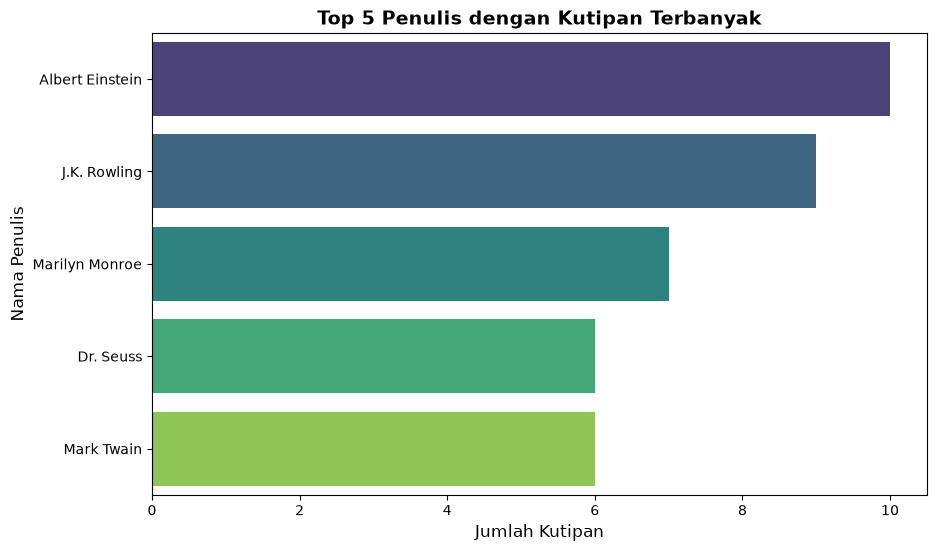

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung jumlah kutipan per penulis dan mengambil 5 teratas
top_authors = df['author'].value_counts().head(5)

# Membuat grafik Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='viridis')

# Menambahkan label dan judul
plt.title('Top 5 Penulis dengan Kutipan Terbanyak', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Kutipan', fontsize=12)
plt.ylabel('Nama Penulis', fontsize=12)

# Menampilkan grafik
plt.show()